# Tokopedia

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv('tokopedia.csv')
df

,nama produk,harga,jumlah
0,Denpoo Mesin Cuci 2 Tabung DW 9292 4P Kapasita...,Rp1.532.000.00,750+ terjual
1,Arashi Laundry AWM 452A Mesin Cuci 1 Tabung 4....,Rp1.442.800.00,500+ terjual
2,MESIN CUCI 1 TABUNG AQUA JAPAN AQW 77 DH / FW...,Rp2.450.000.00,1rb+ terjual
3,Mesin Cuci 1 Tabung AQUA QW 77 DH 7.5 KG Hijab...,Rp2.381.000.00,250+ terjual
4,Sanken Mesin Cuci Twin Tub TW-882BP 9kg Mesin ...,Rp2.600.000.00,750+ terjual
...,...,...,...
64,Google TV 50 Inch Hisense U6K 50 ULED TV Quant...,Rp7.490.000.00,1 terjual
65,LG Freezer GN-INV304BK ( Black ) / FREEZER LG ...,Rp4.199.388.00,1 terjual
66,AQUA CHEST FREEZER AQF-500 W/ LEMARI PEMBEKU/ ...,Rp7.999.000.00,4 terjual
67,SAMSUNG RT31CG5420B1SE / RT31 Kulkas 2 Pintu w...,Rp6.699.000.00,50+ terjual


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   nama produk  69 non-null     object
 1   harga        69 non-null     object
 2   jumlah       69 non-null     object
dtypes: object(3)
memory usage: 1.7+ KB


In [29]:
df.jumlah.unique()

array(['750+ terjual', '500+ terjual', '1rb+ terjual', '250+ terjual',
       '2rb+ terjual', '6rb+ terjual', '3rb+ terjual', '100+ terjual',
       '10rb+ terjual', '5rb+ terjual', '40+ terjual', '30+ terjual',
       '2 terjual', '7 terjual', '11 terjual', '5 terjual', '25 terjual',
       '9 terjual', '6 terjual', '3 terjual', '20 terjual', '1 terjual',
       '16 terjual', '4 terjual', '50+ terjual', '60+ terjual'],
      dtype=object)

In [31]:
# ubah harga jadi int
df["harga"] = df["harga"].str.rsplit(".", n=1).str[0]  # Hapus .00 di paling belakang
df["harga"] = (
    df["harga"].str.replace(r"\D", "", regex=True).astype(int)
)

# ubah jumlah jadi angka
def parse_terjual(val):
    if not isinstance(val, str):
        return val
    val = (
        val.lower()
        .replace("+", "")
        .replace("terjual", "")
        .replace(",", ".")
        .strip()
    )
    if "rb" in val:
        return int(float(val.replace("rb", "").strip()) * 1000)
    else:
        return int(float(val)) if val else 0
df["jumlah"] = df["jumlah"].apply(parse_terjual)

In [33]:
df

,nama produk,harga,jumlah
0,Denpoo Mesin Cuci 2 Tabung DW 9292 4P Kapasita...,1532000,750
1,Arashi Laundry AWM 452A Mesin Cuci 1 Tabung 4....,1442800,500
2,MESIN CUCI 1 TABUNG AQUA JAPAN AQW 77 DH / FW...,2450000,1000
3,Mesin Cuci 1 Tabung AQUA QW 77 DH 7.5 KG Hijab...,2381000,250
4,Sanken Mesin Cuci Twin Tub TW-882BP 9kg Mesin ...,2600000,750
...,...,...,...
64,Google TV 50 Inch Hisense U6K 50 ULED TV Quant...,7490000,1
65,LG Freezer GN-INV304BK ( Black ) / FREEZER LG ...,4199388,1
66,AQUA CHEST FREEZER AQF-500 W/ LEMARI PEMBEKU/ ...,7999000,4
67,SAMSUNG RT31CG5420B1SE / RT31 Kulkas 2 Pintu w...,6699000,50


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69 entries, 0 to 68
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   nama produk  69 non-null     object
 1   harga        69 non-null     int32 
 2   jumlah       69 non-null     int64 
dtypes: int32(1), int64(1), object(1)
memory usage: 1.5+ KB


In [37]:
#simpan data
#df.to_csv("tokopedia_clean.csv", index=False)

## Statistik Tokopedia

### harga

In [46]:
pd.options.display.float_format = '{:.2f}'.format
df['harga'].describe()

count         69.00
mean     5438820.65
std     12153057.91
min        55000.00
25%       533700.00
50%      2381000.00
75%      5519000.00
max     77999000.00
Name: harga, dtype: float64

In [48]:
print("Median:", df['harga'].median())
print("Skewness:", df['harga'].skew())
print("Kurtosis:", df['harga'].kurtosis())
print(df['harga'].quantile([0.25, 0.5, 0.75]))
iqr = df['harga'].quantile(0.75) - df['harga'].quantile(0.25)
print("IQR:", iqr)

Median: 2381000.0
Skewness: 4.89064422622286
Kurtosis: 25.51822815379438
0.25    533700.00
0.50   2381000.00
0.75   5519000.00
Name: harga, dtype: float64
IQR: 4985300.0


### jumlah

In [50]:
df['jumlah'].describe()

count      69.00
mean      756.81
std      1600.70
min         1.00
25%         9.00
50%       100.00
75%       750.00
max     10000.00
Name: jumlah, dtype: float64

In [52]:
print("Median:", df['jumlah'].median())
print("Skewness:", df['jumlah'].skew())
print("Kurtosis:", df['jumlah'].kurtosis())
print(df['jumlah'].quantile([0.25, 0.5, 0.75]))
iqr = df['jumlah'].quantile(0.75) - df['jumlah'].quantile(0.25)
print("IQR:", iqr)

Median: 100.0
Skewness: 3.8269497808000024
Kurtosis: 17.601195441915852
0.25     9.00
0.50   100.00
0.75   750.00
Name: jumlah, dtype: float64
IQR: 741.0


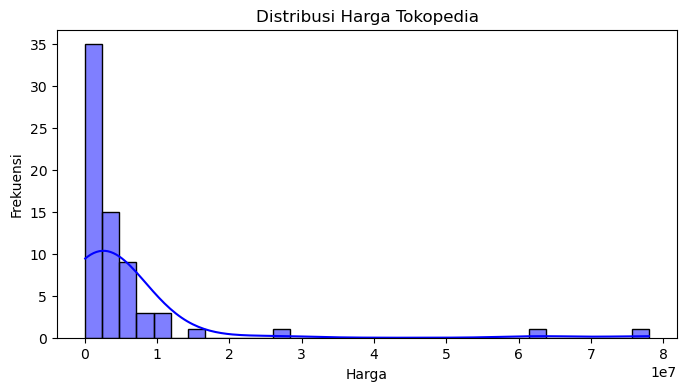

In [56]:
plt.figure(figsize=(8, 4))
sns.histplot(df['harga'], kde=True, color='blue')
plt.title('Distribusi Harga Tokopedia')
plt.xlabel('Harga')
plt.ylabel('Frekuensi')
plt.show()

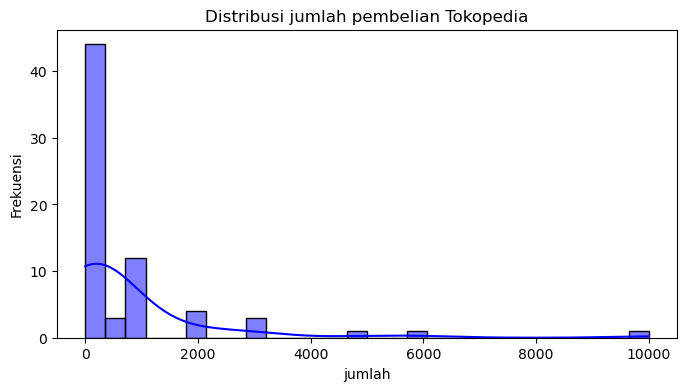

In [60]:
plt.figure(figsize=(8, 4))
sns.histplot(df['jumlah'], kde=True, color='blue')
plt.title('Distribusi jumlah pembelian Tokopedia')
plt.xlabel('jumlah')
plt.ylabel('Frekuensi')
plt.show()

### kategori

In [67]:
df = pd.read_csv('tokopedia_clean.csv')
df

,nama produk,harga,jumlah,kategori
0,Denpoo Mesin Cuci 2 Tabung DW 9292 4P Kapasita...,1532000,750,Mesin Cuci
1,Arashi Laundry AWM 452A Mesin Cuci 1 Tabung 4....,1442800,500,Mesin Cuci
2,MESIN CUCI 1 TABUNG AQUA JAPAN AQW 77 DH / FW...,2450000,1000,Mesin Cuci
3,Mesin Cuci 1 Tabung AQUA QW 77 DH 7.5 KG Hijab...,2381000,250,Mesin Cuci
4,Sanken Mesin Cuci Twin Tub TW-882BP 9kg Mesin ...,2600000,750,Mesin Cuci
...,...,...,...,...
64,Google TV 50 Inch Hisense U6K 50 ULED TV Quant...,7490000,1,TV
65,LG Freezer GN-INV304BK ( Black ) / FREEZER LG ...,4199388,1,Kulkas
66,AQUA CHEST FREEZER AQF-500 W/ LEMARI PEMBEKU/ ...,7999000,4,Kulkas
67,SAMSUNG RT31CG5420B1SE / RT31 Kulkas 2 Pintu w...,6699000,50,Kulkas


In [69]:
df['kategori'].describe()

count     69
unique    11
top       AC
freq      10
Name: kategori, dtype: object

In [77]:
df['kategori'].value_counts()

kategori
AC             10
TV             10
Mesin Cuci      9
Oven            8
Kulkas          8
Vacuum          7
Setrika         7
Rice Cooker     7
Knob            1
Blender         1
Baterai HT      1
Name: count, dtype: int64

C:\Users\Bocah\AppData\Local\Temp\ipykernel_16952\4035460201.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_kategori.values, y=top_kategori.index, palette='viridis')


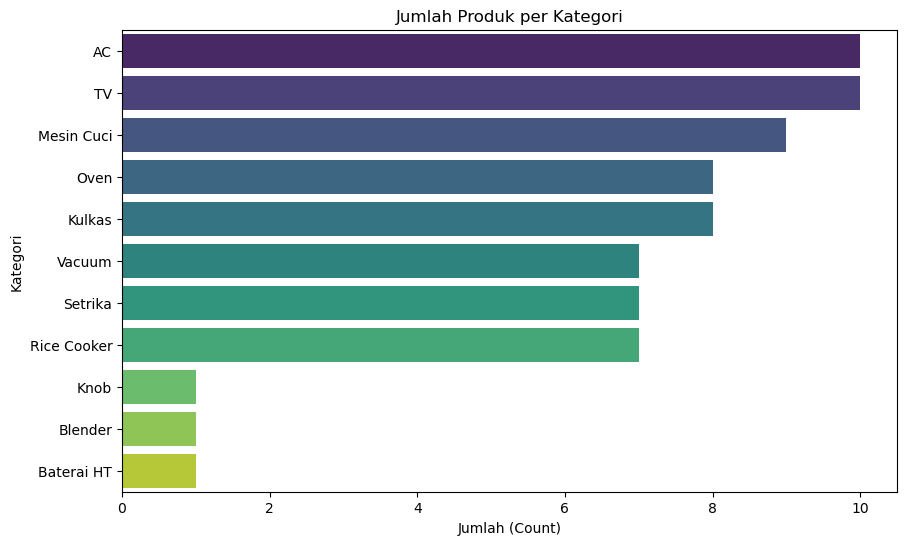

In [83]:

# Hitung jumlah item per kategori dan urutkan
top_kategori = df['kategori'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=top_kategori.values, y=top_kategori.index, palette='viridis')
plt.title('Jumlah Produk per Kategori')
plt.xlabel('Jumlah (Count)')
plt.ylabel('Kategori')
plt.show()

# Shopee

In [130]:
df = pd.read_csv('shopee.csv')
df

,nama produk,harga,jumlah
0,Lampu Tumblr Kawat Mini 1-5M LED Diskon,"Rp2,298",10RB+ sold
1,Gogolampu LED Hias Tumbler Bunga Balon,"Rp2,281",10RB+ sold
2,Lampu LED 3 Mata 12V Roshan 6011,"Rp1,470",10RB+ sold
3,Lampu LED Neon Flex 220V Waterproof 1M-100M,"Rp5,800",10RB+ sold
4,GOGOLAND E005 Lampu Lilin elektrik LED,"Rp1,879",10RB+ sold
5,ANG SARUNG JARI / SARUNG JEMPOL GAME,"Rp2,600",10RB+ sold
6,Lampu Hias LED 1M 10 LED Indoor Outdoor,"Rp2,176",10RB+ sold
7,BG Lampu Tumblr Mini 1-5M LED 3 Mode,"Rp2,274",10RB+ sold
8,"Kapasitor Kipas Angin CBB61 1.2UF, 1.5UF","Rp2,750",10RB+ sold
9,Klem LED Strip Transparan / Klem Lampu,Rp900,10RB+ sold


In [132]:
df['nama produk'].nunique()

60

In [134]:
# Hapus 'Rp' dan tanda koma, lalu ubah ke int
df['harga'] = df['harga'].str.replace('Rp', '', regex=False) \
                         .str.replace(',', '', regex=False) \
                         .astype(int)

In [136]:
df['jumlah'].unique()

array(['10RB+ sold'], dtype=object)

In [138]:
#karena memilih 10.000 semua kita akan langsung ubah
df['jumlah'] = 10000

In [140]:
df.head(5)

,nama produk,harga,jumlah
0,Lampu Tumblr Kawat Mini 1-5M LED Diskon,2298,10000
1,Gogolampu LED Hias Tumbler Bunga Balon,2281,10000
2,Lampu LED 3 Mata 12V Roshan 6011,1470,10000
3,Lampu LED Neon Flex 220V Waterproof 1M-100M,5800,10000
4,GOGOLAND E005 Lampu Lilin elektrik LED,1879,10000


## Statistik

### harga

In [144]:
pd.options.display.float_format = '{:.2f}'.format
df['harga'].describe()

count      60.00
mean     7603.45
std     14246.17
min       300.00
25%      1574.75
50%      2500.00
75%      5800.00
max     99000.00
Name: harga, dtype: float64

In [146]:
print("Median:", df['harga'].median())
print("Skewness:", df['harga'].skew())
print("Kurtosis:", df['harga'].kurtosis())
print(df['harga'].quantile([0.25, 0.5, 0.75]))
iqr = df['harga'].quantile(0.75) - df['harga'].quantile(0.25)
print("IQR:", iqr)

Median: 2500.0
Skewness: 4.819076651573049
Kurtosis: 28.970112099341193
0.25   1574.75
0.50   2500.00
0.75   5800.00
Name: harga, dtype: float64
IQR: 4225.25


### jumlah

In [149]:
df['jumlah'].describe()

count      60.00
mean    10000.00
std         0.00
min     10000.00
25%     10000.00
50%     10000.00
75%     10000.00
max     10000.00
Name: jumlah, dtype: float64

In [151]:
print("Median:", df['jumlah'].median())
print("Skewness:", df['jumlah'].skew())
print("Kurtosis:", df['jumlah'].kurtosis())
print(df['jumlah'].quantile([0.25, 0.5, 0.75]))
iqr = df['jumlah'].quantile(0.75) - df['jumlah'].quantile(0.25)
print("IQR:", iqr)

Median: 10000.0
Skewness: 0.0
Kurtosis: 0.0
0.25   10000.00
0.50   10000.00
0.75   10000.00
Name: jumlah, dtype: float64
IQR: 0.0


### Viz

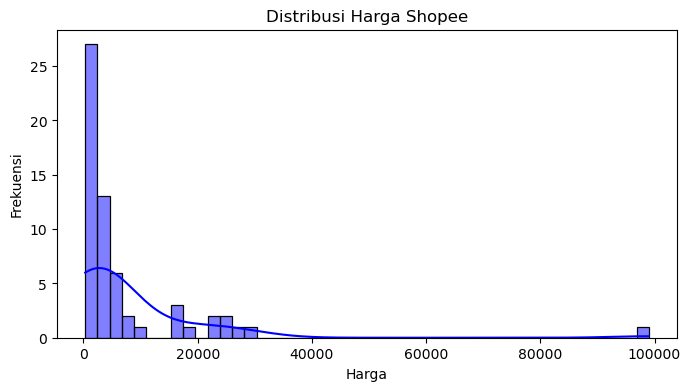

In [154]:
plt.figure(figsize=(8, 4))
sns.histplot(df['harga'], kde=True, color='blue')
plt.title('Distribusi Harga Shopee')
plt.xlabel('Harga')
plt.ylabel('Frekuensi')
plt.show()

In [156]:
#simpan data
#df.to_csv("shopee_clean.csv", index=False)

In [158]:
df = pd.read_csv('shopee_clean.csv')
df

,nama produk,harga,jumlah,kategori
0,Lampu Tumblr Kawat Mini 1-5M LED Diskon,2298,10000,Lampu
1,Gogolampu LED Hias Tumbler Bunga Balon,2281,10000,Lampu
2,Lampu LED 3 Mata 12V Roshan 6011,1470,10000,Lampu
3,Lampu LED Neon Flex 220V Waterproof 1M-100M,5800,10000,Lampu
4,GOGOLAND E005 Lampu Lilin elektrik LED,1879,10000,Lampu
5,ANG SARUNG JARI / SARUNG JEMPOL GAME,2600,10000,Sarung Jari
6,Lampu Hias LED 1M 10 LED Indoor Outdoor,2176,10000,Lampu
7,BG Lampu Tumblr Mini 1-5M LED 3 Mode,2274,10000,Lampu
8,"Kapasitor Kipas Angin CBB61 1.2UF, 1.5UF",2750,10000,Kapasitor Kipas Angin
9,Klem LED Strip Transparan / Klem Lampu,900,10000,Lampu


In [164]:
df['kategori'].value_counts()

kategori
Lampu                    34
Stop Kontak              10
Sarung Jari               4
PCB                       4
Audio                     3
Baterai                   2
Kapasitor Kipas Angin     1
Kabel                     1
Baling-baling Kipas       1
Name: count, dtype: int64

C:\Users\Bocah\AppData\Local\Temp\ipykernel_16952\4035460201.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_kategori.values, y=top_kategori.index, palette='viridis')


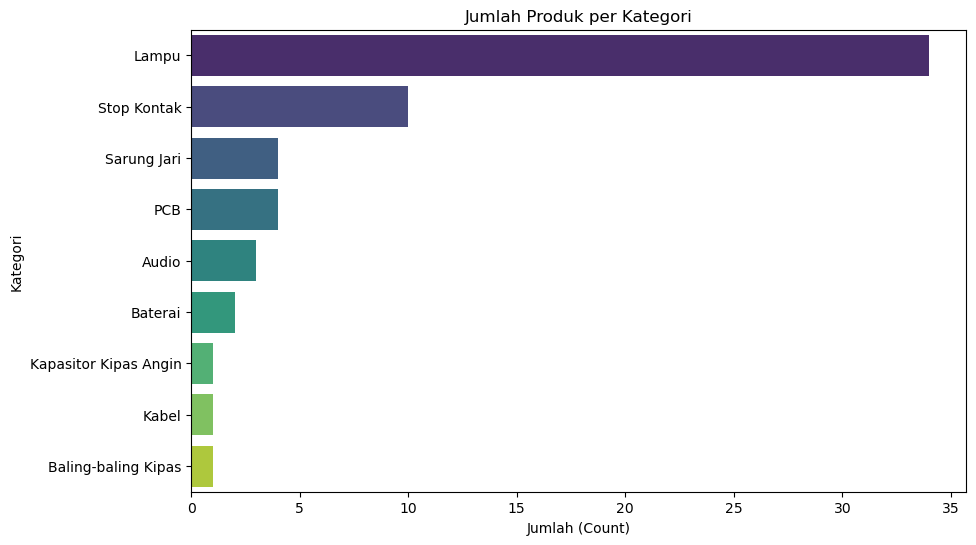

In [166]:

# Hitung jumlah item per kategori dan urutkan
top_kategori = df['kategori'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=top_kategori.values, y=top_kategori.index, palette='viridis')
plt.title('Jumlah Produk pser Kategori')
plt.xlabel('Jumlah (Count)')
plt.ylabel('Kategori')
plt.show()